Load DataSet & check the record count

In [4]:
file = open("Superstore Sales Dataset.csv", "r")

data = file.readlines()

file.close()

print("Number of rows:")
print(len(data))

Number of rows:
9801


What columns exist?
What data types do you see?
Which column represents sales?

Extract Header

In [21]:
header = data[0].strip().split(",")

print(header)

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


Convert Rows into Lists

In [24]:
rows = []

for row in data[1:]:

    values = row.strip().split(",")

    rows.append(values)

print(rows[0])

['1', 'CA-2017-152156', '08/11/2017', '11/11/2017', 'Second Class', 'CG-12520', 'Claire Gute', 'Consumer', 'United States', 'Henderson', 'Kentucky', '42420', 'South', 'FUR-BO-10001798', 'Furniture', 'Bookcases', 'Bush Somerset Collection Bookcase', '261.96']


Count Total Orders

In [27]:
def total_orders(rows):

    return len(rows)

print(total_orders(rows))

9800


Find Total Sale

In [30]:
sales_total = 0

for row in rows:

    sales_total += float(row[-1])

print(sales_total)

2261536.782699953


Create Category Sales Analysis

In [33]:
category_sales = {}

for row in rows:

    category = row[14]

    sales = float(row[-1])

    if category not in category_sales:

        category_sales[category] = 0

    category_sales[category] += sales

print(category_sales)

{'Furniture': 728658.5756999997, 'Office Supplies': 705422.3340000033, 'Technology': 827455.8729999965}


Find Best Category

In [36]:
best_category = max(
    category_sales,
    key=category_sales.get
)

print(best_category)

Technology


Region Sales Analysis

In [41]:
region_sales = {}

for row in rows:

    region = row[12]

    sales = float(row[-1])

    if region not in region_sales:

        region_sales[region] = 0

    region_sales[region] += sales

print(region_sales)

{'South': 389151.4590000004, 'West': 710219.6845000003, 'Central': 492646.9132000005, 'East': 669518.7259999984}


State Sales Analysis

In [46]:
state_sales = {}

for row in rows:

    state = row[10]

    sales = float(row[-1])

    if state not in state_sales:

        state_sales[state] = 0

    state_sales[state] += sales

top_states = sorted(
    state_sales.items(),
    key=lambda x: x[1],
    reverse=True
)

print(top_states[:10])

[('California', 446306.4635000011), ('New York', 306361.147), ('Texas', 168572.53220000005), ('Washington', 135206.84999999995), ('Pennsylvania', 116276.65000000002), ('Florida', 88436.53199999999), ('Illinois', 79236.51699999989), ('Michigan', 76136.07400000002), ('Ohio', 75130.34999999993), ('Virginia', 70636.71999999999)]


Sales by Category

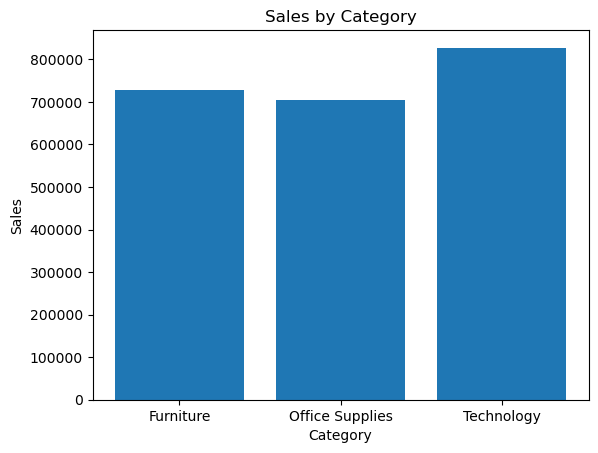

In [49]:
import matplotlib.pyplot as plt

plt.bar(
    category_sales.keys(),
    category_sales.values()
)

plt.title("Sales by Category")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.show()

Sales by Region

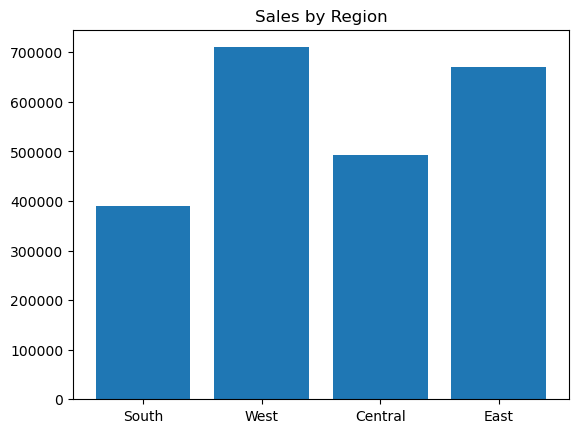

In [52]:
plt.bar(
    region_sales.keys(),
    region_sales.values()
)

plt.title("Sales by Region")

plt.show()

Top 10 States

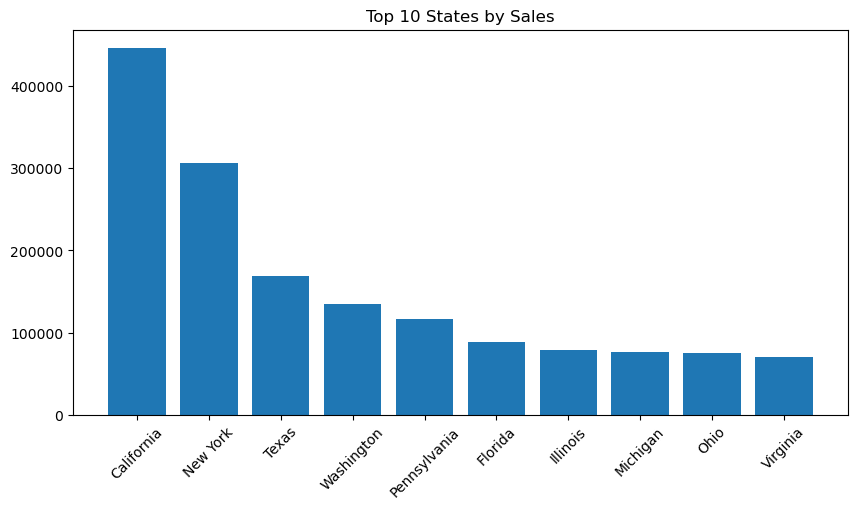

In [55]:
states = []
sales = []

for state, value in top_states[:10]:

    states.append(state)

    sales.append(value)

plt.figure(figsize=(10,5))

plt.bar(states, sales)

plt.xticks(rotation=45)

plt.title("Top 10 States by Sales")

plt.show()

Category Share

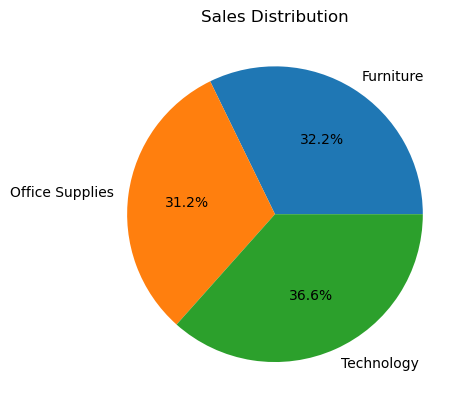

In [58]:
plt.pie(
    category_sales.values(),
    labels=category_sales.keys(),
    autopct="%1.1f%%"
)

plt.title("Sales Distribution")

plt.show()

INSIGHTS

1. Technology generated the highest sales.

2. West region generated the highest revenue.

3. California was the top-performing state.

4. Office Supplies generated significant sales volume.

5. Sales are concentrated in a small number of states.